In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fonctions

In [2]:
# Paramètres
f = 0.005 # 5mm
lambda_0 = 600e-9 # 600nm
nt = 1.0
k0 = (2 * np.pi)/(lambda_0)
kt = (2 * np.pi * nt) / lambda_0
R_pupille = 0.004 # 4mm
NA = R_pupille/f

# Grilles
N = 251
x = np.linspace(-R_pupille, R_pupille, N)
y = np.linspace(-R_pupille, R_pupille, N)
z = np.linspace(-100e-6, 100e-6, 2 * N)
z_micro = z * 1e6
X, Y = np.meshgrid(x, y)
Rp = np.sqrt(X**2 + Y**2)

# Fonctions
def compute_E(E_t, theta, z):
  # Calcule le champs après l'objectif du microscope
  A = -(1j * f)/(lambda_0 * kt**2)
  cos_theta = np.cos(theta)
  kz = kt * cos_theta

  E_apres = np.zeros((N, N, len(z)), dtype = complex)

  for i in range(len(z)):
    exp = f_exp(kz, z[i])

    E_3D = (E_t * exp) / cos_theta
    E_apres[:, :, i] = np.fft.fftshift(np.fft.fft2(E_3D))

  return A * E_apres

def theta_field(X, Y, R, NA):
  # Construit la grille des theta
  r = np.sqrt(X**2 + Y**2)
  a = (r/R) * (NA/nt)
  a = np.clip(a, 0, 1)
  return np.arcsin(a)

def f_exp(kz, z):
  return np.exp(1j * kz * z)

def Plot_output(field_phase): #Plot les graph apres etre passé dans l'objectif de microscope (plot les 3 coupes transversales)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    mid = [s//2 for s in field_phase.shape]
    plt.suptitle('Coupes transversales')

    x_min, x_max = -R_pupille*1e3, R_pupille*1e3
    z_min, z_max = -100, 100

    axes[0].imshow(field_phase[mid[0], :, :], cmap='viridis', aspect='auto', extent=[z_min, z_max, x_max, x_min])
    axes[0].set_xlabel('z (µm)')
    axes[0].set_ylabel('y (mm)')
    axes[0].set_title('Coupe YZ')

    axes[1].imshow(field_phase[:, mid[1], :], cmap='viridis', aspect='auto', extent=[z_min, z_max, x_max, x_min])
    axes[1].set_xlabel('z (µm)')
    axes[1].set_ylabel('x (mm)')
    axes[1].set_title('Coupe XZ')

    axes[2].imshow(field_phase[:, :, mid[2]], cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
    axes[2].set_xlabel('x (mm)')
    axes[2].set_ylabel('y (mm)')
    axes[2].set_title('Coupe XY')

    plt.tight_layout()
    plt.show()


def Plot_input(E_t): # Plot l'amplitude et la phase de l'image dans la pupille d'entré
    Et_ampl = np.abs(E_t)
    Et_arg = np.angle(E_t)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plt.suptitle('Champ en entrée')

    x_min, x_max = -R_pupille*1e3, R_pupille*1e3

    axes[0].imshow(Et_ampl, cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
    axes[0].set_xlabel('x (mm)')
    axes[0].set_ylabel('y (mm)')
    axes[0].set_title('Amplitude du champ')

    axes[1].imshow(Et_arg, cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
    axes[1].set_xlabel('x (mm)')
    axes[1].set_ylabel('y (mm)')
    axes[1].set_title('Phase du champ')

    plt.tight_layout()
    plt.show()

def Plotfaisceau(E_apres):
  # Récupère les indices du tableau 3D des bords du faisceau
  field = np.abs(E_apres)
  mid = [s//2 for s in field.shape]
  upper_yz = np.zeros(len(z))
  lower_yz = np.zeros(len(z))

  for i in range(len(z)): # Dans le plan yz
    idx_max = N
    idx_min = 0
    idx_max_int = np.argmax(field[mid[0], :, i])
    seuil = (1/2) * field[mid[0], idx_max_int, i] # Seuil par rapport au pixel d'intensité max de la colonne

    for j in range(len(y)): # Recherche du pixel de la partie supérieur du faisceau
      if (field[mid[0], len(y) - j - 1, i] > seuil):
        idx_max = len(y) - j - 1
        break

    for j in range(len(y)): # Recherche du pixel de la partie inferieur du faisceau
      if (field[mid[0], j, i] > seuil):
        idx_min = j
        break

    upper_yz[i] = idx_max
    lower_yz[i] = idx_min

  return upper_yz, lower_yz # Ne renvoie que pour l'un des plan car symétrie par rotation autour de l'axe z

theta = theta_field(X, Y, R_pupille, NA) # Grille des theta

# Phénomène d'auto-rétablissement du faisceau d'Airy

In [3]:
def ASP(E_2D, lambda_0, dx, dy, d): # Angular Spectrum Propagator
  Ny, Nx = E_2D.shape

  # Fréquences spatiales
  fx = np.fft.fftfreq(Nx, d=dx)
  fy = np.fft.fftfreq(Ny, d=dy)

  Fx, Fy = np.meshgrid(fx, fy)

  # Facteur de transfert
  kz_temp = k0**2 - (2 * np.pi * Fx)**2 - (2 * np.pi * Fy)**2
  kz = np.sqrt(np.where(kz_temp>=0, kz_temp, 0)) # si negatif, on prend =0 (cas des ondes evanescentes)
  H = np.exp(1j * kz * d)

  # Prop
  E_fft = np.fft.fft2(E_2D)
  E_prop = np.fft.ifft2(E_fft * H)

  return E_prop

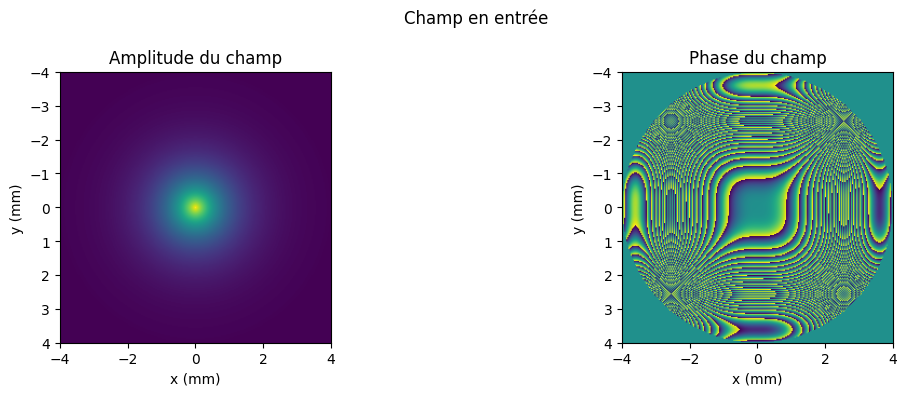

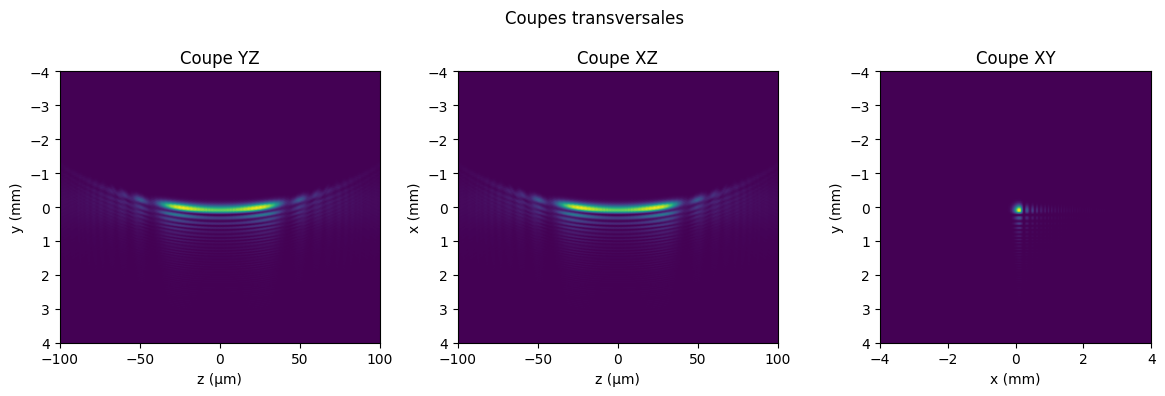

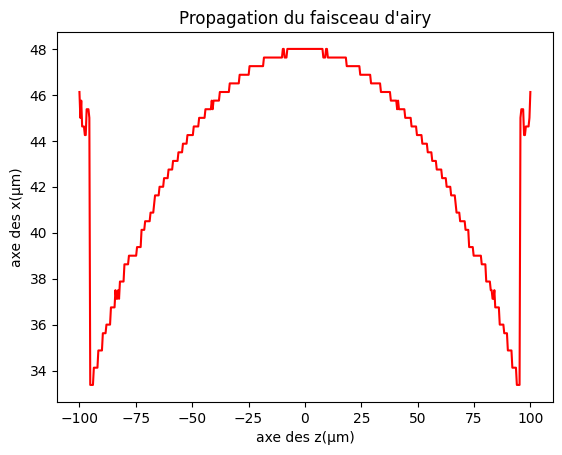

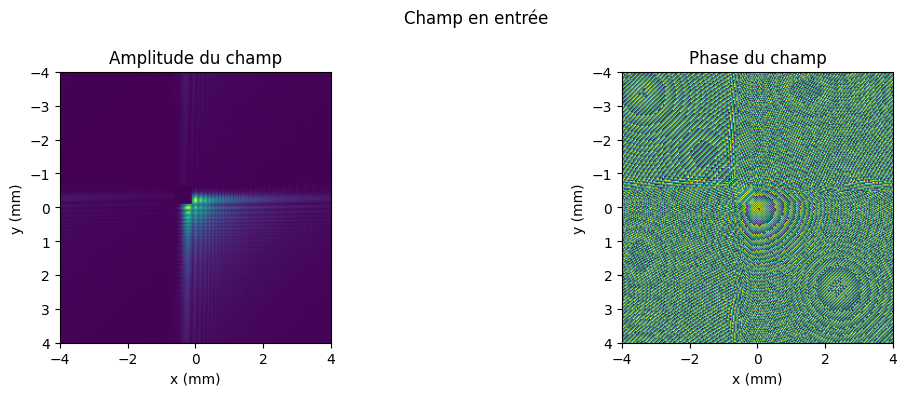

In [4]:
# Paramètres
z = np.linspace(-100e-6, 100e-6, 2 * N)
z_micro = z * 1e6

# Calcule du champs
alpha = 5e9
exp_phase = np.exp(1j * alpha * (X**3 + Y**3))

Et_airy = np.exp(- 5 * (Rp/R_pupille)) * exp_phase # Champs dans la pupille
Et_airy[Rp > R_pupille] = 0 # Champs restreint à la pupille

E_airy = compute_E(Et_airy, theta, z) # Champs après sans phase quadratique

# Plot du champs original
Plot_input(Et_airy)

# Plot du champs après
Plot_output(np.abs(E_airy)**2)

# Propagation du faisceau
max_intensity = []
for i in range(len(z)):
  max_idx_flat = np.argmax(np.abs(E_airy[:, :, i]))
  row, col = np.unravel_index(max_idx_flat, E_airy[:, :, i].shape)
  max_intensity.append((row, col))

max_intensity = np.array(max_intensity)
pixel_size = (lambda_0 * f) / (2 * R_pupille)

# Plot de la propagation du faisceau
z_micro = z*1e6
plt.figure()
plt.plot(z_micro, (max_intensity[:, 1] * pixel_size) * 1e6, color = 'red')
plt.xlabel('axe des z(μm)')
plt.ylabel("axe des x(μm)")
plt.title("Propagation du faisceau d'airy")
plt.show()

# Test propriété d'auto réparation

# Paramètres
E_2D_list = []
mid = [s//2 for s in E_airy.shape]
E_2D = E_airy[:, :, (2 * N)//4]
dx = (2 * R_pupille)/N
dy = (2 * R_pupille)/N
d_list = np.array([5, 10, 15, 20, 30])
d_list = d_list * 1e-3

# Simulation de l'obstacle
square = np.ones((N, N))
#square[N//2 - 3 * N//50:N//2 - N//100 , N//2 - 3 * N//50 :N//2 - N//100] = 0
square[N//2 - 4 * N//50:N//2 - N//80 , N//2 - 4 * N//50:N//2 - N//80] = 0
E_2D_s = E_2D * square
Plot_input(E_2D_s)

# SImulation de la propagation
E_2D_list.append(E_2D_s)
for d in d_list:
  E = ASP(E_2D_s, lambda_0, dx, dy, d)
  E_2D_list.append(E)

E_2D_list1 = np.abs(E_2D_list)
E_2D_list2 = np.angle(E_2D_list)

<Figure size 640x480 with 0 Axes>

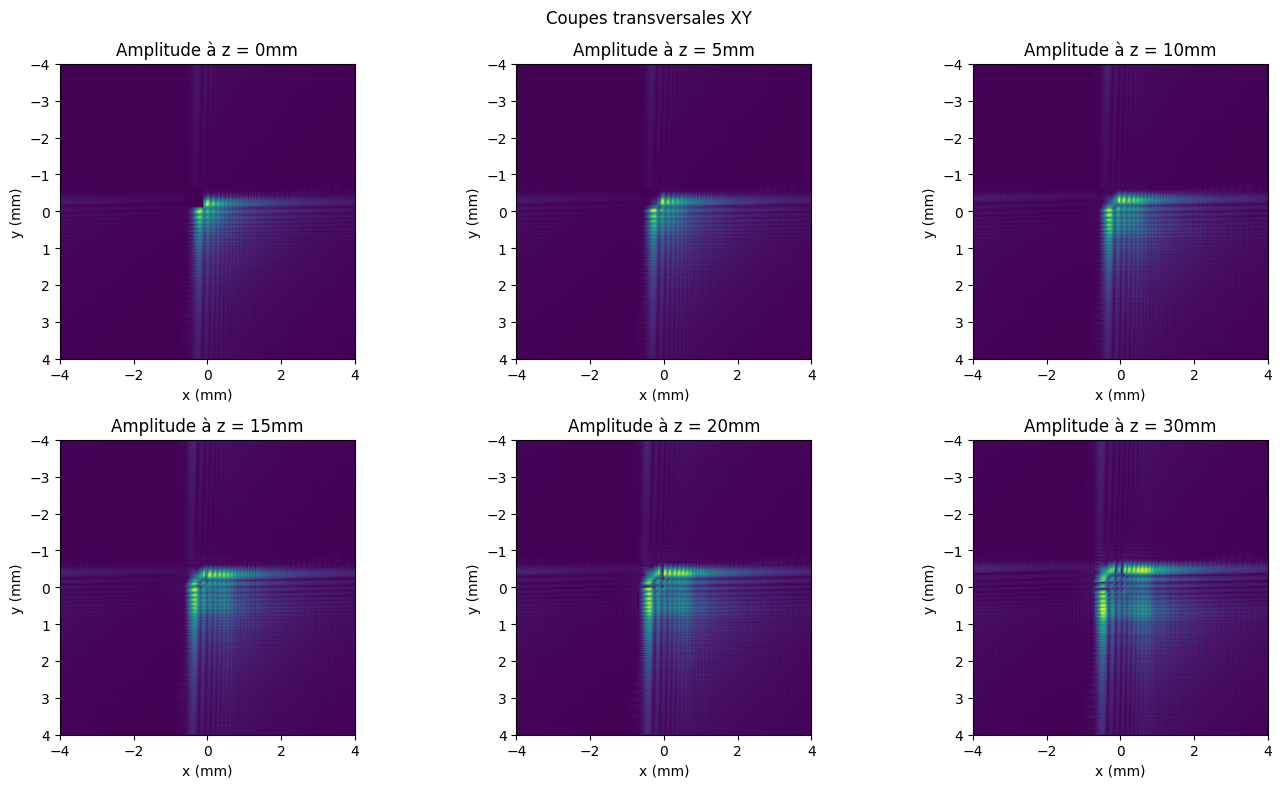

In [5]:
plt.figure()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

x_min, x_max = -R_pupille*1e3, R_pupille*1e3 # en mm
z_min, z_max = -100, 100
plt.suptitle('Coupes transversales XY')

axes[0,0].imshow(E_2D_list1[0], cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
axes[0,0].set_xlabel('x (mm)')
axes[0,0].set_ylabel('y (mm)')
axes[0,0].set_title('Amplitude à z = 0mm')

axes[0,1].imshow(E_2D_list1[1], cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
axes[0,1].set_xlabel('x (mm)')
axes[0,1].set_ylabel('y (mm)')
axes[0,1].set_title('Amplitude à z = 5mm')

axes[0,2].imshow(E_2D_list1[2], cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
axes[0,2].set_xlabel('x (mm)')
axes[0,2].set_ylabel('y (mm)')
axes[0,2].set_title('Amplitude à z = 10mm')

axes[1,0].imshow(E_2D_list1[3], cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
axes[1,0].set_xlabel('x (mm)')
axes[1,0].set_ylabel('y (mm)')
axes[1,0].set_title('Amplitude à z = 15mm')

axes[1,1].imshow(E_2D_list1[4], cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
axes[1,1].set_xlabel('x (mm)')
axes[1,1].set_ylabel('y (mm)')
axes[1,1].set_title('Amplitude à z = 20mm')

axes[1,2].imshow(E_2D_list1[5], cmap='viridis', aspect='equal', extent=[x_min, x_max, x_max, x_min])
axes[1,2].set_xlabel('x (mm)')
axes[1,2].set_ylabel('y (mm)')
axes[1,2].set_title('Amplitude à z = 30mm')

plt.tight_layout()
plt.show()

# Vecteur de Poynting

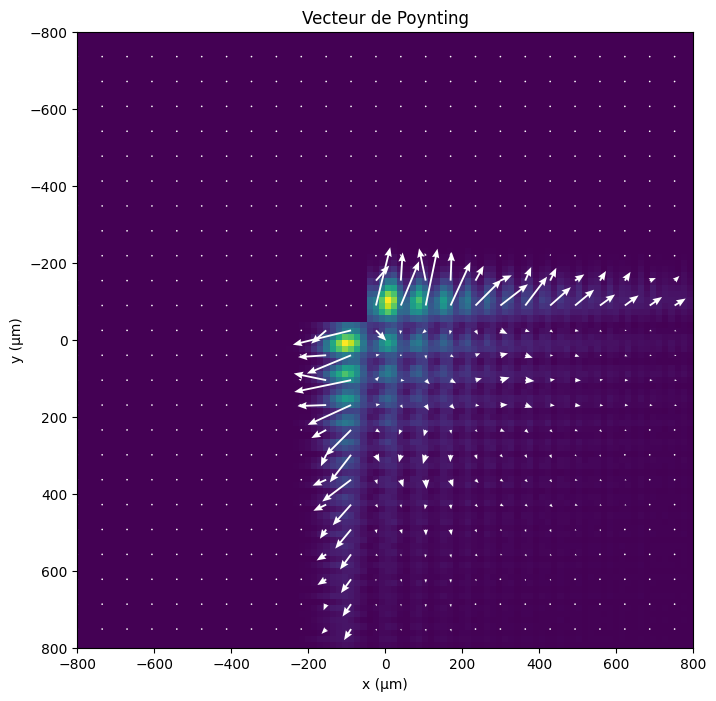

In [6]:
#E = E_airy[:, :, mid[2]]  # sans obstacle
E = E_airy[:,:,N]

zoom = 800  # µm
N_zoom = int(zoom / (R_pupille * 1e6) * E.shape[0])
cx, cy = E.shape[1]//2, E.shape[0]//2

#E_zoom = E[cy-N_zoom:cy+N_zoom, cx-N_zoom:cx+N_zoom]
E_zoom = E_2D_list[0][cy-N_zoom:cy+N_zoom, cx-N_zoom:cx+N_zoom]

dEx = np.gradient(E_zoom, axis=1)
dEy = np.gradient(E_zoom, axis=0)

Px = np.imag(np.conj(E_zoom) * dEx)
Py = np.imag(np.conj(E_zoom) * dEy)

x_zoom = np.linspace(-zoom, zoom, E_zoom.shape[1])
y_zoom = np.linspace(-zoom, zoom, E_zoom.shape[0])

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(np.abs(E_zoom)**2, cmap='viridis',
          extent=[-zoom, zoom, zoom, -zoom])

step = 4
ax.quiver(x_zoom[::step], y_zoom[::step],
          Px[::step, ::step], -Py[::step, ::step],
          color='white', scale=2e-15, width=0.003,
          headwidth=4, headlength=5)

ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title("Vecteur de Poynting")
plt.show()

# FWHM

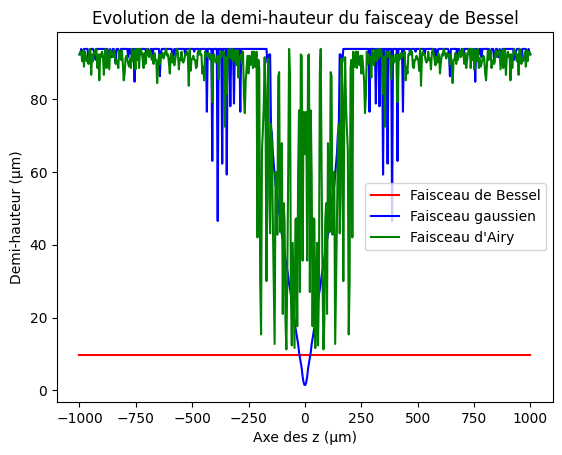

In [7]:
# Paramètres
z = np.linspace(-1000e-6, 1000e-6, 500)
z_micro = z * 1e6
Et_Bessel = np.zeros((N, N)) # Anneau
center_x = N//2
center_y = N//2
radius_inf = (0.5 * N)//30
radius_sup = (0.6 * N)//30

# Faisceau de Bessel

for xi in range(N):
  for yi in range(N):
    if (((np.sqrt((center_x - xi)**2 + (center_y - yi)**2)) >= radius_inf) & ((np.sqrt((center_x - xi)**2 + (center_y - yi)**2) <= radius_sup))):
      Et_Bessel[xi, yi] = 1

E_Bessel = compute_E(Et_Bessel, theta, z) # Champs après du cercle

# Faisceau Gaussien
Et_gausse = np.exp(-10 * (Rp/R_pupille)**2) # Champs gaussien avant la pupille
Et_gausse[Rp > R_pupille] = 0 # Champs restreint à la pupille

E_gausse = compute_E(Et_gausse, theta, z) # Champs après l'objectif

# Faisceau d'Airy
alpha = 1e10
exp_phase = np.exp(1j * alpha * (X**3 + Y**3))

Et_airy = np.exp(-1 * (Rp/R_pupille)) * exp_phase # Champs dans la pupille
Et_airy[Rp > R_pupille] = 0 # Champs restreint à la pupille

E_airy = compute_E(Et_airy, theta, z) # Champs après sans phase quadratique



# Vérification que le faisceau de Bessel ideal (plus l'anneau est fin, plus il est ideal) diverge très peu par rapport au faisceau gaussien
# Pour verifier sur de plus grande distance, il faut reduire la taille de l'anneau et donc augmenter le nombre de pixels (sinon on n'a plus un anneau)
# On observe le meme comportement lorsque l'on reduit le rayon de l'anneau
B_upper_yz, B_lower_yz = Plotfaisceau(E_Bessel)
G_upper_yz, G_lower_yz = Plotfaisceau(E_gausse)
A_upper_yz, A_lower_yz = Plotfaisceau(E_airy)

pixel_size = (lambda_0 * f) / (2 * R_pupille)

demi_hauteur_B = (B_upper_yz - B_lower_yz) * pixel_size * 1e6
demi_hauteur_G = (G_upper_yz - G_lower_yz) * pixel_size * 1e6
demi_hauteur_A = (A_upper_yz - A_lower_yz) * pixel_size * 1e6

plt.figure()
plt.plot(z_micro, demi_hauteur_B, color = 'red')
plt.plot(z_micro, demi_hauteur_G, color = 'blue')
plt.plot(z_micro, demi_hauteur_A, color = 'green')
plt.xlabel('Axe des z (μm)')
plt.ylabel('Demi-hauteur (μm)')
plt.legend(['Faisceau de Bessel', 'Faisceau gaussien', "Faisceau d'Airy"])
plt.title('Evolution de la demi-hauteur du faisceay de Bessel')
plt.show()